In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df=pd.read_csv("Message_Intelligence_Dataset_5200.csv")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

   message_id                                       message_text  \
0      900001  Please find the attached invoice for the updat...   
1      900002  Let's catch up tomorrow regarding the timeline...   
2      900003  Can you send the report by end of day? next Mo...   
3      900004  Can you send the report by end of day? 10:30 A...   
4      900005  Could you review the document and share feedba...   

   message_length  word_count  num_urls  num_digits  num_special_chars  \
0              99          11         1           4                  0   
1              73          12         0           0                  0   
2              67          13         0           0                  0   
3              64          13         0           4                  0   
4              84          14         0           0                  0   

   spam_keyword_score  legit_keyword_score  sender_activity_score  \
0                   0                    1                   56.6   
1       

In [4]:
# PART B

# Q6 - INPUT FEATURES & TARGET

features = [
    "message_length",
    "word_count",
    "num_urls",
    "num_digits",
    "num_special_chars",
    "spam_keyword_score",
    "legit_keyword_score",
    "sender_activity_score",
    "sender_account_age_days",
    "messages_sent_last_24h",
    "hour_of_day",
    "day_of_week"
]

X = df[features]
y = df["spam_label"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(y.name)

print("\nTarget Distribution:")
print(y.value_counts())

# Q7 - DATA PREPROCESSING

print("Missing Values:")
print(X.isnull().sum())

imputer = KNNImputer(n_neighbors=5)

X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

print("\nPreprocessing Completed")
print("Scaled Data Shape:", X_scaled.shape)

# Q8 - TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTrain Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Class Distribution:")
print(y_test.value_counts(normalize=True))

Input Features:
['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']

Target Variable:
spam_label

Target Distribution:
spam_label
0    4227
1     973
Name: count, dtype: int64
Missing Values:
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
hour_of_day                  0
day_of_week                  0
dtype: int64

Preprocessing Completed
Scaled Data Shape: (5200, 12)
Training Data Shape: (4160, 12)
Testing Data Shape: (1040, 12)

Train Class Distribution:
spam_label
0    0.812981
1    0.187019
Name: proportion, dtype: float64

Test Class Distribution:

KNN Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040

    K  Accuracy  Precision  Recall   F1
0   3       1.0        1.0     1.0  1.0
1   5       1.0        1.0     1.0  1.0
2   7       1.0        1.0     1.0  1.0
3   9       1.0        1.0     1.0  1.0
4  11       1.0        1.0     1.0  1.0
Best K: 3


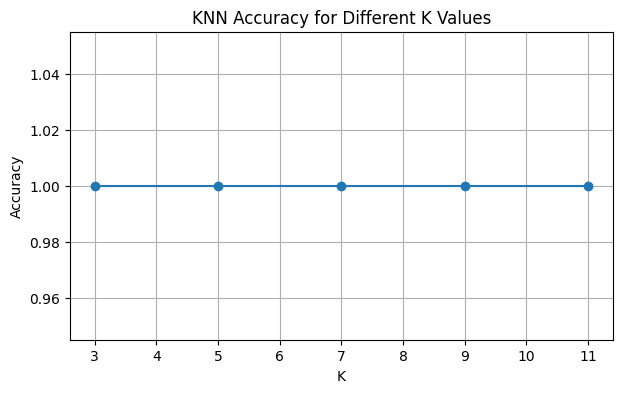

      Metric  Accuracy  Precision  Recall   F1
0  euclidean       1.0        1.0     1.0  1.0
1  manhattan       1.0        1.0     1.0  1.0
   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0


In [6]:
# PART C
# Q9 - KNN CLASSIFIER

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

# Q10 - DIFFERENT K VALUES

k_results = []

for k in [3, 5, 7, 9, 11]:
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    k_results.append([
        k,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

k_df = pd.DataFrame(
    k_results,
    columns=["K", "Accuracy", "Precision", "Recall", "F1"]
)

print(k_df.round(4))

best_k = k_df.loc[k_df["F1"].idxmax(), "K"]

print("Best K:", best_k)

plt.figure(figsize=(7,4))

plt.plot(k_df["K"], k_df["Accuracy"], marker="o")

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

# Q11 - DISTANCE METRICS

distance_results = []

for metric in ["euclidean", "manhattan"]:
    
    model = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    distance_results.append([
        metric,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

distance_df = pd.DataFrame(
    distance_results,
    columns=["Metric", "Accuracy", "Precision", "Recall", "F1"]
)

print(distance_df.round(4))

# Q12 - MISCLASSIFIED MESSAGES

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train, y_train)

knn_pred = best_knn.predict(X_test)

test_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": knn_pred
})
print(test_results.head())


In [7]:
# PART D
# Q13 - SVM CLASSIFIERS

svm_models = {
    "Linear": SVC(
        kernel="linear",
        probability=True,
        random_state=42
    ),
    
    "RBF": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),
    
    "Polynomial": SVC(
        kernel="poly",
        probability=True,
        random_state=42
    )
}

svm_results = []

for name, model in svm_models.items():
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    svm_results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

svm_df = pd.DataFrame(
    svm_results,
    columns=[
        "Kernel",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(svm_df.round(4))

# Q14 - SUPPORT VECTORS

linear_svm = svm_models["Linear"]

print("Number of Support Vectors:")
print(linear_svm.n_support_)

print("\nTotal Support Vectors:",
      linear_svm.support_.shape[0])

# Q15 - SVM VS KNN

comparison = svm_df.copy()

knn_row = pd.DataFrame([{
    "Kernel": "KNN",
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision": precision_score(y_test, knn_pred),
    "Recall": recall_score(y_test, knn_pred),
    "F1": f1_score(y_test, knn_pred)
}])

comparison = pd.concat(
    [knn_row, comparison],
    ignore_index=True
)

print(comparison.round(4))

       Kernel  Accuracy  Precision  Recall   F1
0      Linear       1.0        1.0     1.0  1.0
1         RBF       1.0        1.0     1.0  1.0
2  Polynomial       1.0        1.0     1.0  1.0
Number of Support Vectors:
[7 5]

Total Support Vectors: 12
       Kernel  Accuracy  Precision  Recall   F1
0         KNN       1.0        1.0     1.0  1.0
1      Linear       1.0        1.0     1.0  1.0
2         RBF       1.0        1.0     1.0  1.0
3  Polynomial       1.0        1.0     1.0  1.0


In [8]:
# PART E
# Q16 - NAIVE BAYES

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

# Q17 - CONDITIONAL PROBABILITY

data = df.copy()

data["url_present"] = (data["num_urls"] > 0).astype(int)

p_url_spam = (
    data.loc[data["spam_label"] == 1, "url_present"].mean()
)

p_url_not_spam = (
    data.loc[data["spam_label"] == 0, "url_present"].mean()
)

print("P(URL | Spam):", round(p_url_spam, 4))
print("P(URL | Not Spam):", round(p_url_not_spam, 4))

# Q18 - BAYES THEOREM

p_spam = (data["spam_label"] == 1).mean()
p_not_spam = (data["spam_label"] == 0).mean()

p_url = data["url_present"].mean()

p_spam_given_url = (
    p_url_spam * p_spam
) / p_url

print("P(Spam):", round(p_spam, 4))
print("P(Not Spam):", round(p_not_spam, 4))
print("P(URL):", round(p_url, 4))

print(
    "\nP(Spam | URL):",
    round(p_spam_given_url, 4)
)

# Q19 - THEORY VS MODEL

sample = X_test[:1]

prediction = nb.predict(sample)[0]

probability = nb.predict_proba(sample)[0]

print("Actual:", y_test.iloc[0])
print("Prediction:", prediction)

print("\nP(Not Spam):", round(probability[0], 4))
print("P(Spam):", round(probability[1], 4))

Naive Bayes Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040

P(URL | Spam): 0.739
P(URL | Not Spam): 0.084
P(Spam): 0.1871
P(Not Spam): 0.8129
P(URL): 0.2065

P(Spam | URL): 0.6695
Actual: 0
Prediction: 0

P(Not Spam): 1.0
P(Spam): 0.0


In [9]:
# PART F
# Q20 - MODEL EVALUATION

models = {
    "KNN": knn_pred,
    "SVM Linear": svm_models["Linear"].predict(X_test),
    "SVM RBF": svm_models["RBF"].predict(X_test),
    "SVM Polynomial": svm_models["Polynomial"].predict(X_test),
    "Naive Bayes": nb_pred
}

results = []

for name, pred in models.items():
    
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(results_df.round(4))

# Q21 - MODEL COMPARISON

print(
    results_df.sort_values(
        "F1 Score",
        ascending=False
    ).round(4)
)

# Q22 - BEST PRECISION & RECALL

best_precision = results_df.loc[
    results_df["Precision"].idxmax()
]

best_recall = results_df.loc[
    results_df["Recall"].idxmax()
]

best_f1 = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Highest Precision:")
print(best_precision)

print("\nHighest Recall:")
print(best_recall)

print("\nHighest F1 Score:")
print(best_f1)

            Model  Accuracy  Precision  Recall  F1 Score
0             KNN       1.0        1.0     1.0       1.0
1      SVM Linear       1.0        1.0     1.0       1.0
2         SVM RBF       1.0        1.0     1.0       1.0
3  SVM Polynomial       1.0        1.0     1.0       1.0
4     Naive Bayes       1.0        1.0     1.0       1.0
            Model  Accuracy  Precision  Recall  F1 Score
0             KNN       1.0        1.0     1.0       1.0
1      SVM Linear       1.0        1.0     1.0       1.0
2         SVM RBF       1.0        1.0     1.0       1.0
3  SVM Polynomial       1.0        1.0     1.0       1.0
4     Naive Bayes       1.0        1.0     1.0       1.0
Highest Precision:
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object

Highest Recall:
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object

Highest F1 Score:
Model        KNN
Accuracy     1.0
Precision  

Best Model: KNN

Confusion Matrix:
[[845   0]
 [  0 195]]

True Negative (TN): 845
False Positive (FP): 0
False Negative (FN): 0
True Positive (TP): 195


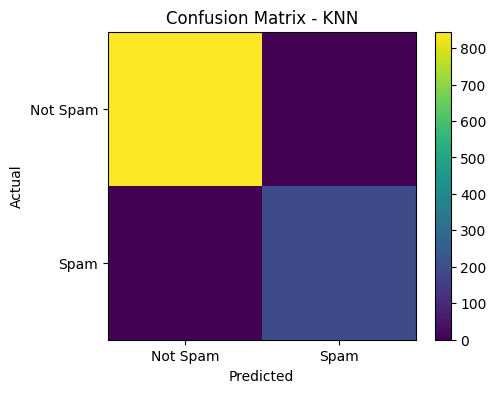

In [10]:
# CONFUSION MATRIX - BEST MODEL

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_pred = models[best_model_name]

cm = confusion_matrix(y_test, best_pred)

print("Best Model:", best_model_name)
print("\nConfusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Spam", "Spam"])
plt.yticks([0, 1], ["Not Spam", "Spam"])

plt.colorbar()

plt.show()

In [11]:
# PART G
# Q23 - FINAL ANALYSIS

best_accuracy = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

best_precision_name = results_df.loc[
    results_df["Precision"].idxmax(),
    "Model"
]

best_recall_name = results_df.loc[
    results_df["Recall"].idxmax(),
    "Model"
]

best_f1_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("""
FINAL PROJECT ANALYSIS
======================

1. KNN:
   Strength - Simple and intuitive distance-based classifier.
   Weakness - Prediction can be slower for large datasets.

2. SVM:
   Strength - Effective for separating complex classes.
   Weakness - Kernel and parameter selection can affect performance.

3. Naive Bayes:
   Strength - Fast and probability-based classification.
   Weakness - Assumes feature independence.

4. Evaluation:
   Accuracy, Precision, Recall and F1-score were used
   to evaluate the classifiers.

5. Business Recommendation:
   For spam detection, Recall is important because
   missing a spam message can be undesirable.
   Precision is also important to avoid incorrectly
   blocking legitimate messages.
""")

print("Best Accuracy Model :", best_accuracy)
print("Best Precision Model:", best_precision_name)
print("Best Recall Model   :", best_recall_name)
print("Best F1 Model       :", best_f1_name)

# Q24 - FINAL SUBMISSION CHECK

print("""
PROJECT SUBMISSION
==================

✓ Dataset loaded
✓ Data preprocessing completed
✓ Train/Test split completed
✓ KNN implemented
✓ Different K values tested
✓ Distance metrics compared
✓ Misclassified messages analyzed
✓ Linear SVM implemented
✓ RBF SVM implemented
✓ Polynomial SVM implemented
✓ Support vectors analyzed
✓ Naive Bayes implemented
✓ Conditional probability calculated
✓ Bayes Theorem demonstrated
✓ Accuracy calculated
✓ Precision calculated
✓ Recall calculated
✓ F1 Score calculated
✓ Confusion Matrix generated
✓ Models compared
✓ Final recommendation prepared
""")


FINAL PROJECT ANALYSIS

1. KNN:
   Strength - Simple and intuitive distance-based classifier.
   Weakness - Prediction can be slower for large datasets.

2. SVM:
   Strength - Effective for separating complex classes.
   Weakness - Kernel and parameter selection can affect performance.

3. Naive Bayes:
   Strength - Fast and probability-based classification.
   Weakness - Assumes feature independence.

4. Evaluation:
   Accuracy, Precision, Recall and F1-score were used
   to evaluate the classifiers.

5. Business Recommendation:
   For spam detection, Recall is important because
   missing a spam message can be undesirable.
   Precision is also important to avoid incorrectly
   blocking legitimate messages.

Best Accuracy Model : KNN
Best Precision Model: KNN
Best Recall Model   : KNN
Best F1 Model       : KNN

PROJECT SUBMISSION

✓ Dataset loaded
✓ Data preprocessing completed
✓ Train/Test split completed
✓ KNN implemented
✓ Different K values tested
✓ Distance metrics compared
✓ Mi

In [12]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "SVM RBF": SVC(kernel="rbf"),
    "Naive Bayes": GaussianNB()
}.items():
    
    scores = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5,
        scoring="f1"
    )
    
    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean F1", "Std F1"]
)

print(cv_df.round(4))

         Model  Mean F1  Std F1
0          KNN      1.0     0.0
1      SVM RBF      1.0     0.0
2  Naive Bayes      1.0     0.0
